In [4]:
import scanpy as sc
import scvelo as scv
import numpy as np
import pandas as pd

# Plot
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.spatial import Delaunay
from scipy.spatial import ConvexHull
from scipy.interpolate import splprep, splev

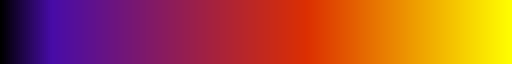

In [2]:
# Visualization setup: update `var` and `obsm`
import pyensembl as en
from pyensembl import EnsemblRelease
import os
os.environ['PYENSEMBL_CACHE_DIR'] = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/cell2location'

data = EnsemblRelease(100)

# Define a custom color ramp function
def colorRamp2(colors, positions):
    cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', list(zip(positions, colors)))
    return cmap

# Specify colors and their positions (0 to 1)
positions = [0, 0.1, 0.6, 1]  # Adjust position to shift purple leftward
colors = ['black',  '#480ca8', '#dc2f02', 'yellow']

# Generate the custom colormap
my_custom_colormap = colorRamp2(colors, positions)
my_custom_colormap

#myWR = mcolors.LinearSegmentedColormap.from_list("myWR", ['#64f5f7', '#f589a2',"#f42f5c"], gamma=0.8)
#blueyellow = mcolors.LinearSegmentedColormap.from_list("myWR", [
#"#352A86", "#343296", "#343AA7", "#2646BB", "#1156D0", "#0366DE", "#0A76D8", "#1286D2", "#1C99C0", "#27ADAC", "#46B897", "#78BB7E", "#A9BD67", "#CCBC57", "#EFBA47", "#F7C438", "#F6D12B", "#F6DF1F", "#F7EC16", "#F8FA0D"
#], gamma=0.8)

In [3]:
adata_bgi = sc.read_h5ad('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/cell2location3/results/hsc_analysis/cell2location_map/sp_gw17.h5ad')
adata_bgi

AnnData object with n_obs × n_vars = 27405 × 8504
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', '_indices', '_scvi_batch', '_scvi_labels', 'APC_cycling', 'APC_dorsal', 'APC_ventral', 'AST', 'COP', 'EC', 'ExN_immature_1', 'ExN_immature_2', 'ExN_immature_3', 'ExN_mature_1', 'ExN_mature_2', 'ExN_mature_3', 'ExN_naive', 'ExN_ventral', 'FP', 'IPC', 'InN_immature_1', 'InN_immature_2', 'InN_mature_1', 'InN_mature_2', 'InN_naive', 'InN_ventral_1', 'InN_ventral_2', 'InN_ventral_3', 'MFOL', 'MN1', 'MN2', 'MOL', 'MP', 'Microglia', 'NPC', 'NPC_proliferative', 'OPC', 'PC', 'RP', 'VLMC'
    var: 'name', 'SYMBOL', 'MT_gene'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod'
    obsm: 'MT', 'X_cod', 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf'
    layers: 'APC_cycling', 'APC_dorsal', 'APC_ventral', 'AST', 'COP', 'EC', 'ExN_immature_1', 'ExN_immature_2', 'ExN_immature_3', 'ExN_ma

In [4]:
adata_bgi.obs.index

Index(['GW17:12480_19290', 'GW17:12540_18780', 'GW17:15300_19440',
       'GW17:12120_19650', 'GW17:15480_18840', 'GW17:14520_19170',
       'GW17:11610_20940', 'GW17:15990_19080', 'GW17:15480_19590',
       'GW17:13920_19680',
       ...
       'GW17:16710_20580', 'GW17:12420_17340', 'GW17:15810_19470',
       'GW17:12750_17130', 'GW17:11670_18240', 'GW17:15060_17370',
       'GW17:12720_17190', 'GW17:12660_17730', 'GW17:14970_17220',
       'GW17:16050_22050'],
      dtype='object', length=27405)

In [5]:
adata_bgi

AnnData object with n_obs × n_vars = 27405 × 8504
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', '_indices', '_scvi_batch', '_scvi_labels', 'APC_cycling', 'APC_dorsal', 'APC_ventral', 'AST', 'COP', 'EC', 'ExN_immature_1', 'ExN_immature_2', 'ExN_immature_3', 'ExN_mature_1', 'ExN_mature_2', 'ExN_mature_3', 'ExN_naive', 'ExN_ventral', 'FP', 'IPC', 'InN_immature_1', 'InN_immature_2', 'InN_mature_1', 'InN_mature_2', 'InN_naive', 'InN_ventral_1', 'InN_ventral_2', 'InN_ventral_3', 'MFOL', 'MN1', 'MN2', 'MOL', 'MP', 'Microglia', 'NPC', 'NPC_proliferative', 'OPC', 'PC', 'RP', 'VLMC'
    var: 'name', 'SYMBOL', 'MT_gene'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod'
    obsm: 'MT', 'X_cod', 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf'
    layers: 'APC_cycling', 'APC_dorsal', 'APC_ventral', 'AST', 'COP', 'EC', 'ExN_immature_1', 'ExN_immature_2', 'ExN_immature_3', 'ExN_ma

In [6]:
target_celltypes = [
    "NPC_proliferative", "NPC", "IPC",
    "ExN_naive", "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral", 
    "InN_naive", "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3", 
    "MN1", "MN2", 
    "APC_cycling", "APC_dorsal", "APC_ventral", "AST",
    "OPC", "COP", "MFOL", "MOL", 
    "RP", "MP", "FP", 
    "Schwann", "EC", "VLMC", "PC", "Microglia"
]

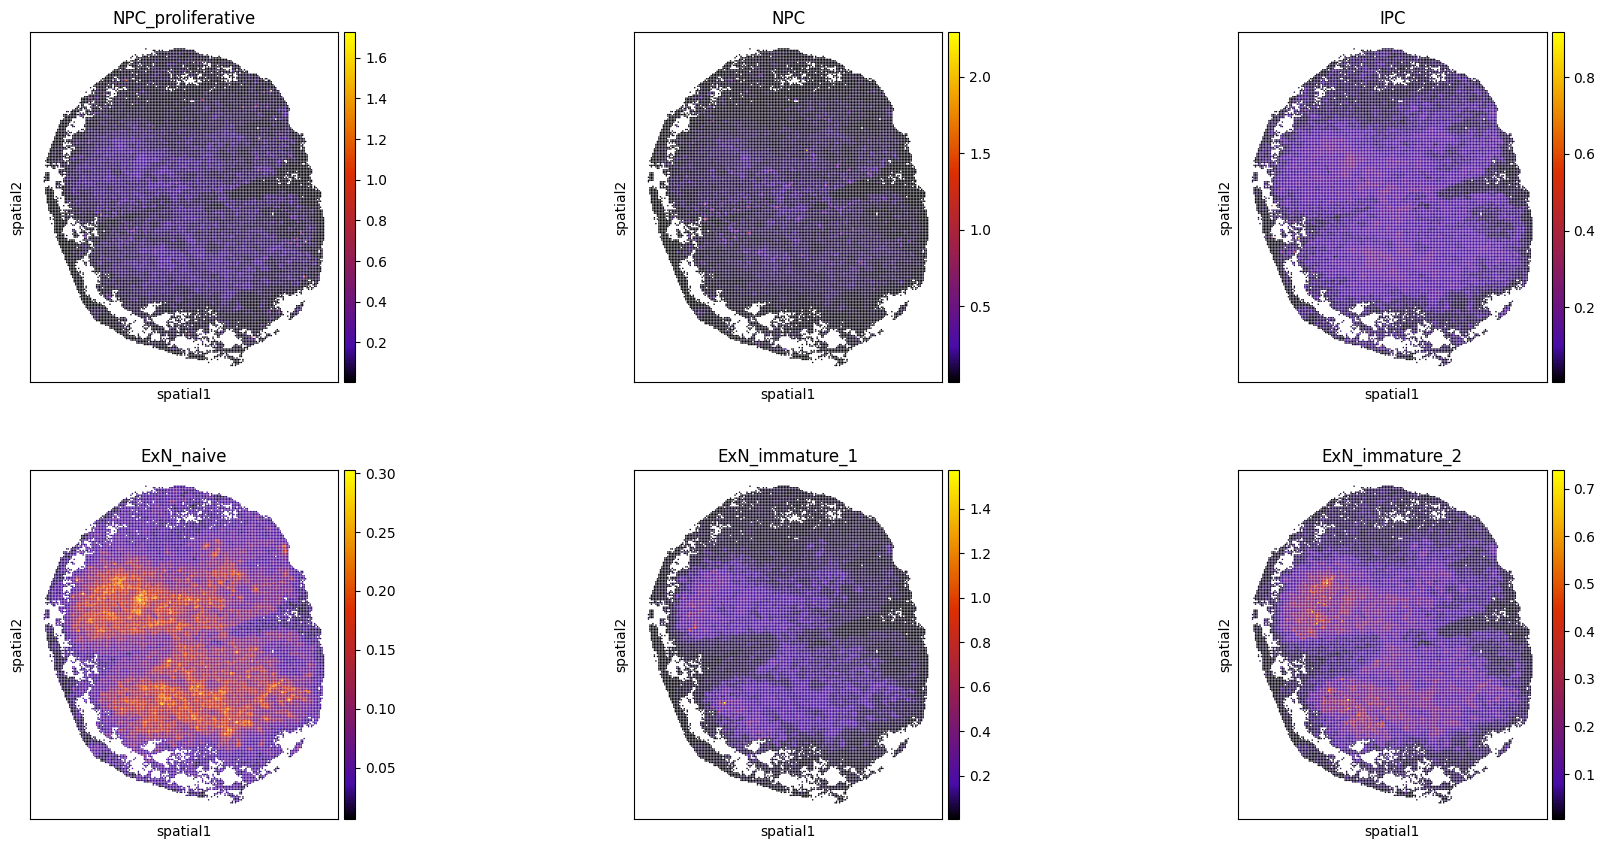

In [7]:
import scanpy as sc
import matplotlib.pyplot as plt

# Plot the first few example cell types
sc.pl.spatial(
    adata_bgi, 
    color=target_celltypes[:6],  # Plot the first 6 cell types
    ncols=3,               # Display 3 panels per row
    spot_size=30,          # Adjust spot size according to your coordinate system
    cmap=my_custom_colormap,           # Red-toned or viridis-like maps are commonly used for probability distributions
    gene_symbols='SYMBOL',
    # vmax=2.0,
    # vmin=0
)

In [3]:
# color from meijiao
my_colors = {
    #----------Pro----------
    'NPC_proliferative' : '#D27BA1',
    'NPC' : 'darkgreen',
    'IPC' : '#D10049',

    #----------EX-----------
    'ExN_naive' : '#F2684C',
    'ExN_immature_1' : '#94191D',    
    'ExN_immature_2' : '#31A352',
    'ExN_immature_3' : '#0A0288',
    'ExN_mature_1' : '#6066AF',
    'ExN_mature_2' : '#600073',
    'ExN_mature_3' : '#3182BE',
    'ExN_ventral' : '#9594CB',
    
    #----------IN-----------
    'InN_naive' : '#FFEBB2',
    'InN_immature_1' : '#FFAA7B',
    'InN_immature_2' : '#D0696A',
    'InN_mature_1' : '#841D50',
    'InN_mature_2' : '#E63D53',
    'InN_ventral_1': '#C2C9D7',
    'InN_ventral_2': '#CE0011',
    'InN_ventral_3': '#6D006A',

    #----------MN-----------
    'MN1' : '#8E0B1B',
    'MN2' : '#AEE4EA',

    #---------Astrocyte Precursors & Astrocytes---------
    'APC_cycling' : '#D15500',
    'APC_dorsal' : '#20A6E7',
    'APC_ventral' : '#0055A9',
    'AST' : '#007854',

    #---------Oligodendrocyte Lineage---------
    'OPC' : '#5C5857',
    'COP' : '#83B3D4',
    'MFOL' : '#F0A8B1',
    'MOL' : '#FFD686',

    #---------Ependymal-----------
    'RP' : '#FBA700',
    'MP' : '#F09600',
    'FP' : '#FFDD2A',

    #---------Other-----------
    'VLMC' : '#FEFFC4',
    'EC' : '#eca9b8',
    'Schwann' : '#ba6eac',
    'PC' : '#cb909d',
    'Microglia' : '#DFB8B3'
}

In [ ]:
import pandas as pd
import scanpy as sc
import numpy as np
import anndata as ad

# 1. Automatically determine the sample prefix (e.g. "GW7" or "GW12")
sample_prefix = adata_bgi.obs_names[0].split(':')[0]
print(f"Detected sample prefix: {sample_prefix}")

# 2. Read the full spatial coordinate CSV
csv_path = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/visualization3/spatial_coord.csv"
df_all_coords = pd.read_csv(csv_path, index_col=0)

# 3. Filter cells in the CSV according to the prefix
df_filtered = df_all_coords[df_all_coords.index.str.startswith(sample_prefix)].copy()
print(f"Total number of cells in the CSV matching {sample_prefix}: {len(df_filtered)}")

# 4. Identify cells missing from `adata_bgi`
missing_indices = df_filtered.index.difference(adata_bgi.obs_names)
print(f"Number of low-quality cells to be restored: {len(missing_indices)}")

# 5. Build an AnnData object for the missing cells
X_missing = np.zeros((len(missing_indices), adata_bgi.n_vars))

adata_missing = ad.AnnData(
    X=X_missing,
    obs=pd.DataFrame(index=missing_indices),
    var=adata_bgi.var.copy() 
)

# 6. Set the `lowq` label
adata_bgi.obs['lowq'] = 0        
adata_missing.obs['lowq'] = 1    

# 7. Merge the data
adata_augmented = ad.concat(
    [adata_bgi, adata_missing], 
    axis=0, 
    join='outer', 
    merge='first', 
    uns_merge='first'
)

# ================== New step: convert NaN to 0 ==================
# Identify all numeric columns in `obs` (including cell-type probabilities, nCount, etc.)
# Restored cells currently have NaN values in these columns, so they need to be filled with 0
numeric_cols = adata_augmented.obs.select_dtypes(include=[np.number]).columns
adata_augmented.obs[numeric_cols] = adata_augmented.obs[numeric_cols].fillna(0)
# ================================================================

# 8. Update the spatial coordinates for all cells
# Make sure the coordinate order matches the merged index
adata_augmented.obsm['spatial'] = df_filtered.loc[adata_augmented.obs_names, ['x', 'y']].values
adata_augmented.obsm['X_spatial'] = adata_augmented.obsm['spatial']

print(f"Restoration and cleanup completed. The new object contains {adata_augmented.n_obs} cells.")
print(f"lowq summary:\n{adata_augmented.obs['lowq'].value_counts()}")

# Verify that the maximum cell-type probability is now restored to a normal range (rather than being fixed at 1.0)
# print(adata_augmented.obs[target_cts].max())

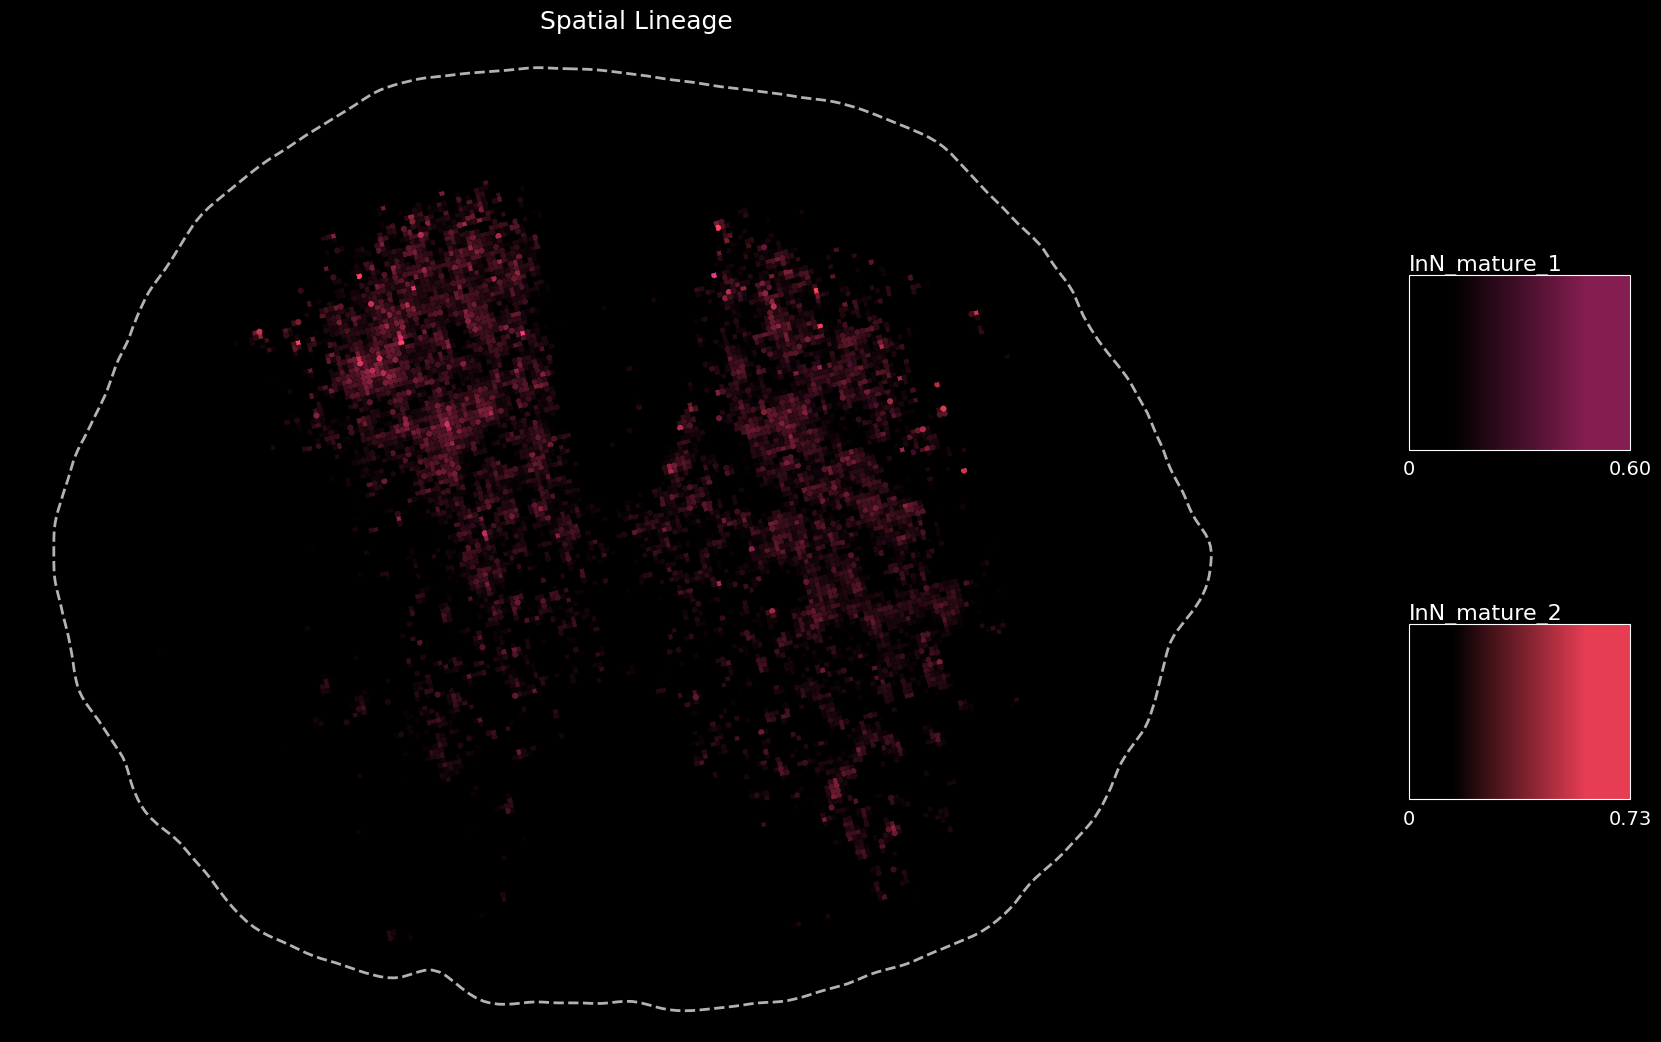

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, LinearSegmentedColormap, Normalize
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.ndimage import binary_dilation, gaussian_filter
from skimage import measure

def create_contrast_cmap(base_color):
    return LinearSegmentedColormap.from_list(
        'contrast_cmap',
        [(0, 'black'), (0.2, 'black'), (0.8, base_color), (1, base_color)]
    )

def rotate_coords_geometric(coords, angle_degrees):
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(((c, -s), (s, c)))
    x_min, y_min = np.min(coords, axis=0)
    x_max, y_max = np.max(coords, axis=0)
    center = np.array([(x_min + x_max) / 2, (y_min + y_max) / 2])
    return np.dot(coords - center, R.T) + center

def plot_spatial_lineage(adata, cell_types, my_colors, spot_size=100, expand_dist=3, power=1.2, rotate_angle=0):
    # 1. Prepare and rotate coordinates
    raw_coords = adata.obsm['X_spatial'] if 'X_spatial' in adata.obsm else adata.obsm['spatial']
    coords = rotate_coords_geometric(raw_coords, rotate_angle)
    x, y = coords[:, 0], coords[:, 1]
    
    # 2. Compute blended colors
    mixed_rgb = np.zeros((adata.n_obs, 3))
    vmax_list = []
    cmaps = []

    for ct in cell_types:
        base_color = my_colors.get(ct, '#FFFFFF')
        weights = adata.obs[ct].values.copy()
        ct_vmax = weights.max() if weights.max() > 0 else 1
        vmax_list.append(ct_vmax)
        
        # Create a segmented high-contrast colormap
        cmap = create_contrast_cmap(base_color)
        cmaps.append(cmap)
        
        # To make the main panel follow a black-to-gradient-to-color logic,
        # apply nonlinear mapping to the weights
        norm_w = weights / ct_vmax
        # Apply a piecewise mapping: values below 0.2 become 0, above 0.8 become 1, and values in between are linearly interpolated
        interp_w = np.interp(norm_w, [0, 0.2, 0.8, 1.0], [0, 0, 1, 1])
        # Then combine the original power parameters to fine-tune the contrast.
        interp_w = np.power(interp_w, power)
        
        base_color_rgb = np.array(to_rgb(base_color))
        mixed_rgb += np.outer(interp_w, base_color_rgb)

    # Brightness normalization processing
    max_val = mixed_rgb.max(axis=1, keepdims=True)
    max_val[max_val == 0] = 1
    mixed_rgb /= max_val
    # The intensity is determined by the original weight, ensuring that areas with no signal are black.
    intensity = np.max([np.interp(adata.obs[ct].values / adata.obs[ct].max(), [0, 0.2, 0.8, 1], [0, 0, 1, 1]) for ct in cell_types], axis=0)
    mixed_rgb *= intensity[:, np.newaxis]

    # 3. canvas layout
    fig = plt.figure(figsize=(18, 11), facecolor='black')
    gs = GridSpec(1, 2, width_ratios=[8.5, 1.5], figure=fig)
    
    # main
    ax = fig.add_subplot(gs[0])
    ax.set_facecolor('black')
    ax.set_aspect('equal', adjustable='datalim')
    ax.scatter(x, y, c=mixed_rgb, s=spot_size, marker='o', edgecolors='none')

    # 4. edge lines
    res = 150
    x_grid = ((x - x.min()) / (x.max() - x.min()) * (res-1)).astype(int)
    y_grid = ((y - y.min()) / (y.max() - y.min()) * (res-1)).astype(int)
    mask_arr = np.zeros((res + 20, res + 20))
    mask_arr[y_grid + 10, x_grid + 10] = 1.0
    mask_dilated = binary_dilation(mask_arr > 0.5, iterations=expand_dist)
    mask_smoothed = gaussian_filter(mask_dilated.astype(float), sigma=2.0)
    contours = measure.find_contours(mask_smoothed, 0.4)
    for contour in contours:
        cx = (contour[:, 1] - 10) / (res-1) * (x.max() - x.min()) + x.min()
        cy = (contour[:, 0] - 10) / (res-1) * (y.max() - y.min()) + y.min()
        ax.plot(cx, cy, color='white', linestyle='--', linewidth=2, alpha=0.7)

    # 5. right Colorbars (apply high contrast gradient)
    gs_right = GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[1], height_ratios=[2, 6, 2])
    gs_legend = GridSpecFromSubplotSpec(len(cell_types), 1, subplot_spec=gs_right[1], hspace=1.0)
    
    for i, ct in enumerate(cell_types):
        cax = fig.add_subplot(gs_legend[i])
        norm = Normalize(vmin=0, vmax=vmax_list[i])
        sm = plt.cm.ScalarMappable(cmap=cmaps[i], norm=norm)
        
        cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
        cb.outline.set_edgecolor('white')
        cb.set_ticks([0, vmax_list[i]])
        cb.ax.set_xticklabels(['0', f'{vmax_list[i]:.2f}'], color='white', fontsize=14)
        cax.set_title(ct, color='white', loc='left', fontsize=16, pad=3)
        cax.set_facecolor('black')

    # 6. decoration
    ax.axis('off')
    margin = 0.05
    ax.set_xlim(x.min() - (x.max()-x.min())*margin, x.max() + (x.max()-x.min())*margin)
    ax.set_ylim(y.min() - (y.max()-y.min())*margin, y.max() + (y.max()-y.min())*margin)
    ax.set_title("Spatial Lineage", color='white', fontsize=18, pad=10)
    plt.subplots_adjust(left=0.02, right=0.92, top=0.95, bottom=0.05)
    
    return fig

# --- run ---
# target_cts = ['EC', 'VLMC']
# target_cts = ['RP', 'MP', "FP"]
# target_cts = ['MOL']
target_cts = ["InN_mature_1", "InN_mature_2",]
# target_cts = ["MN1", "MN2"]

fig = plot_spatial_lineage(
    adata_augmented, 
    target_cts, 
    my_colors, 
    spot_size=20,      # gw6:140; gw7:100; gw9:60; gw10:50; gw12:40; gw16:20; gw17:20
    power=0.5,
    rotate_angle=284,  # gw6:250; gw7:17; gw9:205; gw10:200; gw12:180; gw16:125; gw17:284
    expand_dist=3      # gw6:3;   gw7:3;  gw9:2;   gw10:6; gw12:3; gw16:3; gw17:3
)

plt.show()

In [2]:
target_celltypes = [
    "NPC_proliferative", "NPC", "IPC",
    "ExN_naive", "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral", 
    "InN_naive", "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3", 
    "MN1", "MN2", 
    "APC_cycling", "APC_dorsal", "APC_ventral", "AST",
    "OPC", "COP", "MFOL", "MOL", 
    "RP", "MP", "FP", 
    "Schwann", "EC", "VLMC", "PC", "Microglia"
]

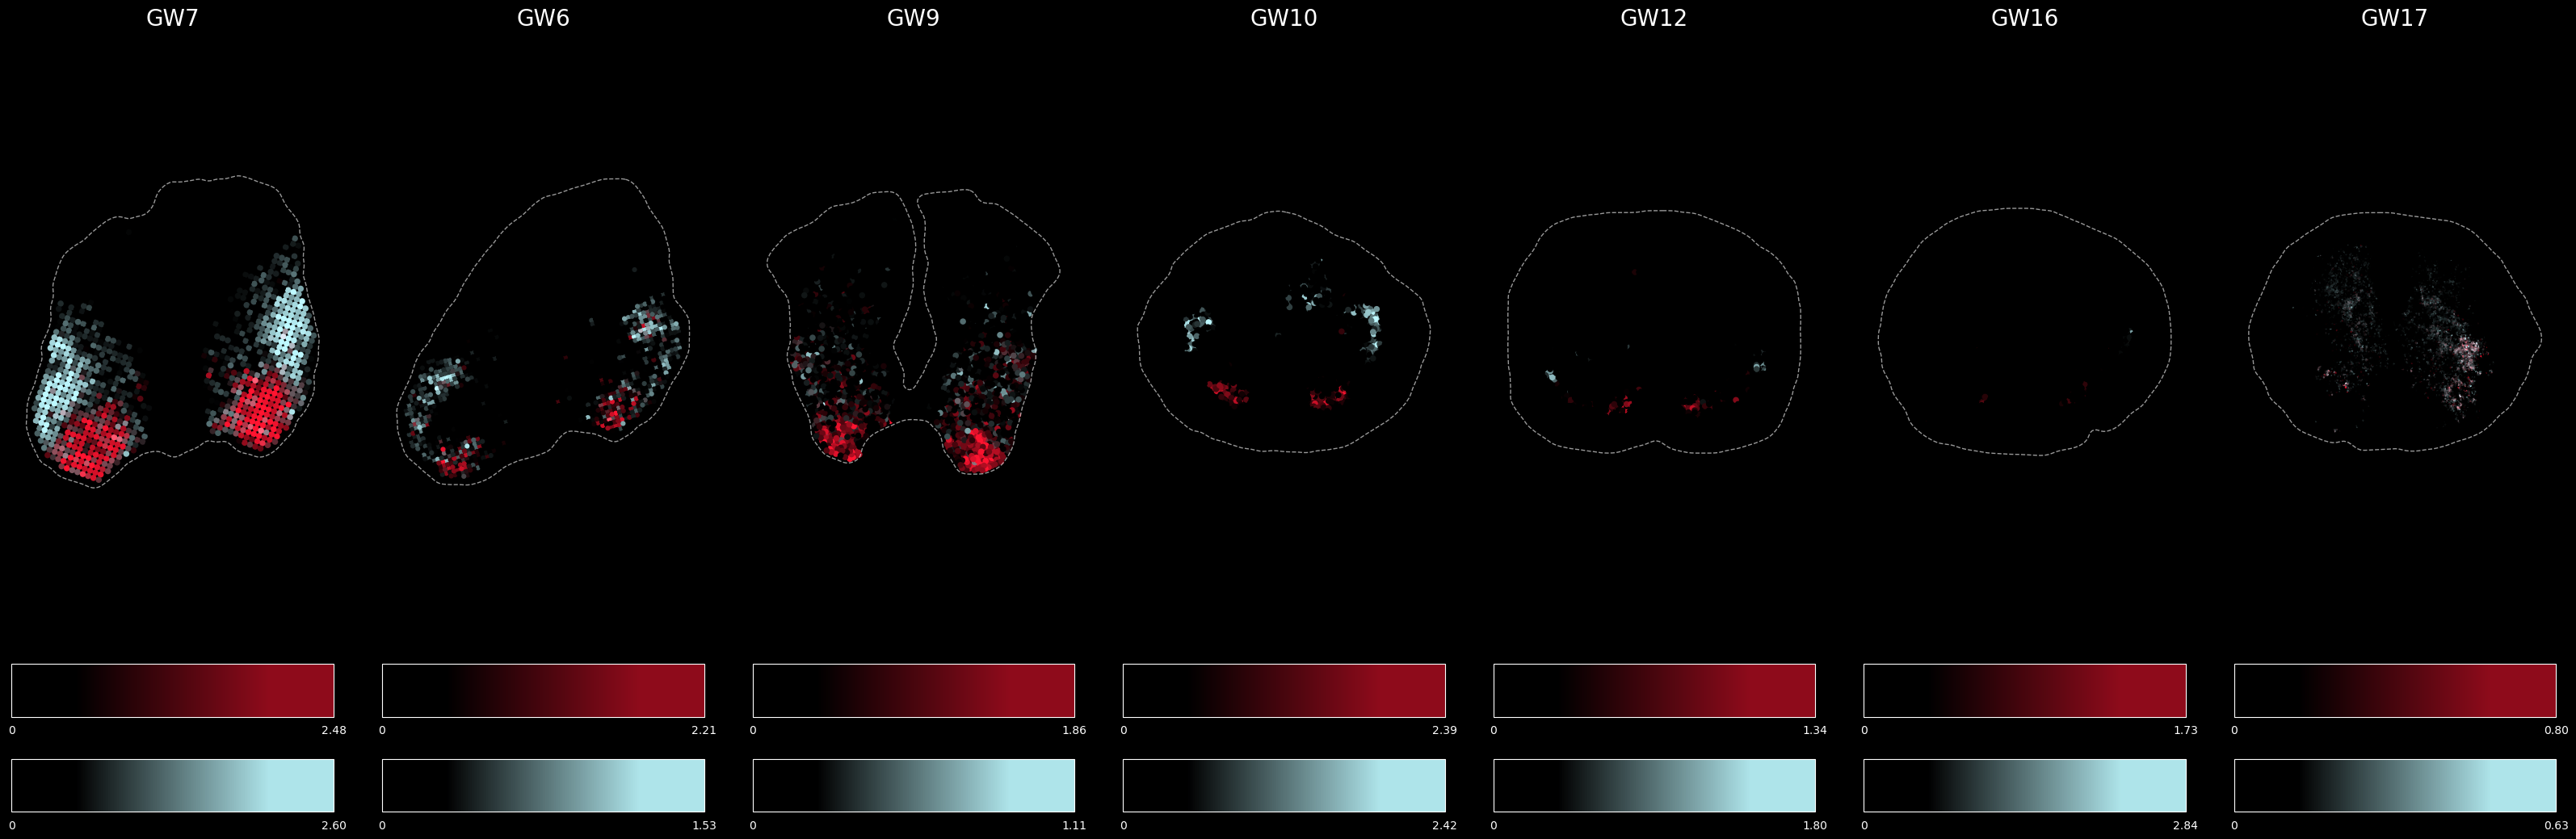

In [ ]:
import pandas as pd
import scanpy as sc
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, LinearSegmentedColormap, Normalize
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.ndimage import binary_dilation, gaussian_filter
from skimage import measure
import os

# ================== core drawing functions ==================
def create_contrast_cmap(base_color):
    return LinearSegmentedColormap.from_list('contrast_cmap', [(0, 'black'), (0.2, 'black'), (0.8, base_color), (1, base_color)])

def rotate_coords_geometric(coords, angle_degrees):
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(((c, -s), (s, c)))
    center = np.mean(coords, axis=0)
    return np.dot(coords - center, R.T) + center

def process_and_plot_single(adata, target_cts, my_colors, config, main_ax, colorbar_gs, power=0.5):
    """
    Draw a single sample in a given ax and gs region
    """
    # 1. rotate coordinates
    raw_coords = adata.obsm['spatial']
    coords = rotate_coords_geometric(raw_coords, config['rotate_angle'])
    x, y = coords[:, 0], coords[:, 1]
    
    # 2. calculate mixed colors (replicate your logic)
    mixed_rgb = np.zeros((adata.n_obs, 3))
    vmax_list = []
    cmaps = []
    
    for ct in target_cts:
        base_color = my_colors.get(ct, '#FFFFFF')
        weights = adata.obs[ct].values.copy()
        ct_vmax = weights.max() if weights.max() > 0 else 1e-8
        vmax_list.append(ct_vmax)
        cmaps.append(create_contrast_cmap(base_color))
        
        norm_w = weights / ct_vmax
        interp_w = np.interp(norm_w, [0, 0.2, 0.8, 1.0], [0, 0, 1, 1])
        interp_w = np.power(interp_w, power)
        mixed_rgb += np.outer(interp_w, np.array(to_rgb(base_color)))

    # normalize brightness and intensity
    max_val = mixed_rgb.max(axis=1, keepdims=True)
    max_val[max_val == 0] = 1
    mixed_rgb /= max_val
    
    intensities = []
    for ct in target_cts:
        w_norm = adata.obs[ct].values / (adata.obs[ct].max() + 1e-8)
        intensities.append(np.interp(w_norm, [0, 0.2, 0.8, 1], [0, 0, 1, 1]))
    intensity = np.max(intensities, axis=0)
    mixed_rgb *= intensity[:, np.newaxis]

    # 3. draw main
    main_ax.set_facecolor('black')
    main_ax.set_aspect('equal', adjustable='datalim')
    main_ax.scatter(x, y, c=mixed_rgb, s=config['spot_size'], marker='o', edgecolors='none', rasterized=True)
    
    # 4. draw edge lines
    res = 120
    x_grid = ((x - x.min()) / (x.max() - x.min() + 1e-5) * (res-1)).astype(int)
    y_grid = ((y - y.min()) / (y.max() - y.min() + 1e-5) * (res-1)).astype(int)
    mask_arr = np.zeros((res + 20, res + 20))
    mask_arr[y_grid + 10, x_grid + 10] = 1.0
    mask_dilated = binary_dilation(mask_arr > 0.5, iterations=config['expand_dist'])
    mask_smoothed = gaussian_filter(mask_dilated.astype(float), sigma=2.0)
    contours = measure.find_contours(mask_smoothed, 0.4)
    for contour in contours:
        cx = (contour[:, 1] - 10) / (res-1) * (x.max() - x.min()) + x.min()
        cy = (contour[:, 0] - 10) / (res-1) * (y.max() - y.min()) + y.min()
        main_ax.plot(cx, cy, color='white', linestyle='--', linewidth=1, alpha=0.6)
    
    main_ax.axis('off')
    main_ax.set_title(adata.obs_names[0].split(':')[0], color='white', fontsize=20, pad=10)

    # 5. draw the Colorbars at the bottom of the column
    for i, ct in enumerate(target_cts):
        cax = plt.gcf().add_subplot(colorbar_gs[i])
        norm = Normalize(vmin=0, vmax=vmax_list[i])
        sm = plt.cm.ScalarMappable(cmap=cmaps[i], norm=norm)
        cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
        cb.outline.set_edgecolor('white')
        cb.set_ticks([0, vmax_list[i]])
        cb.ax.set_xticklabels(['0', f'{vmax_list[i]:.2f}'], color='white', fontsize=10)
        cax.set_title(ct if colorbar_gs.get_geometry()[1] == 0 else "", color='white', loc='left', fontsize=12) # 仅在第一列显示标题

# ================== run the integrated drawing ==================
def plot_integrated_panels(sample_list, target_cts, my_colors, power=0.5):
    df_all_coords = pd.read_csv(csv_path, index_col=0)
    n_samples = len(sample_list)
    
    # create a super wide canvas (7 samples side by side)
    fig = plt.figure(figsize=(5 * n_samples, 12), facecolor='black')
    
    # each column represents a period
    outer_gs = GridSpec(1, n_samples, figure=fig, wspace=0.15)
    
    for idx, s_id in enumerate(sample_list):
        conf = samples_config[s_id]
        
        # load data
        adata = sc.read_h5ad(os.path.join(base_path, conf['file']))
        sample_prefix = adata.obs_names[0].split(':')[0]
        df_f = df_all_coords[df_all_coords.index.str.startswith(sample_prefix)].copy()
        
        # Complete missing cells
        missing = df_f.index.difference(adata.obs_names)
        if len(missing) > 0:
            adata_m = ad.AnnData(X=np.zeros((len(missing), adata.n_vars)), 
                                 obs=pd.DataFrame(index=missing), var=adata.var.copy())
            adata = ad.concat([adata, adata_m], axis=0, join='outer', merge='first')
            num_cols = adata.obs.select_dtypes(include=[np.number]).columns
            adata.obs[num_cols] = adata.obs[num_cols].fillna(0)
        
        adata.obsm['spatial'] = df_f.loc[adata.obs_names, ['x', 'y']].values
        
        # create a sub-layout in the current column
        inner_gs = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[idx], height_ratios=[8, 2], hspace=0.1)
        
        ax_main = fig.add_subplot(inner_gs[0])
        
        # create a sub-grid for Colorbars
        gs_legend = GridSpecFromSubplotSpec(len(target_cts), 1, subplot_spec=inner_gs[1], hspace=0.8)
        
        # call the drawing
        process_and_plot_single(adata, target_cts, my_colors, conf, ax_main, gs_legend, power=power)

    plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1)
    return fig

# --- run ---
# ==================  Parameter configuration  ==================
base_path = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/cell2location3/results/hsc_analysis/cell2location_map/'
csv_path = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/visualization3/spatial_coord.csv"

# strictly match the parameters you provided
samples_config = {
    "gw6":  {"file": "sp_gw6.h5ad",  "spot_size": 30, "rotate_angle": 250, "expand_dist": 3},
    "gw7":  {"file": "sp_gw7.h5ad",  "spot_size": 20, "rotate_angle": 17,  "expand_dist": 3},
    "gw9":  {"file": "sp_gw9.h5ad",  "spot_size": 30,  "rotate_angle": 205, "expand_dist": 1},
    "gw10": {"file": "sp_gw10.h5ad", "spot_size": 30,  "rotate_angle": 200, "expand_dist": 3},
    "gw12": {"file": "sp_gw12.h5ad", "spot_size": 30,  "rotate_angle": 180, "expand_dist": 3},
    "gw16": {"file": "sp_gw16.h5ad", "spot_size": 30,  "rotate_angle": 125, "expand_dist": 3},
    "gw17": {"file": "sp_gw17.h5ad", "spot_size": 3,  "rotate_angle": 284, "expand_dist": 3}
}
sample_order = ["gw6", "gw7", "gw9", "gw10", "gw12", "gw16", "gw17"]

target_cts = ["MN1", "MN2"]

fig = plot_integrated_panels(sample_order, target_cts, my_colors, power=0.5)
plt.savefig('Integrated_Spatial_Lineage.png', dpi=300, facecolor='black', bbox_inches='tight')
plt.show()

Drawing gw6...
Drawing gw7...
Drawing gw9...
Drawing gw10...
Drawing gw12...
Drawing gw16...
Drawing gw17...


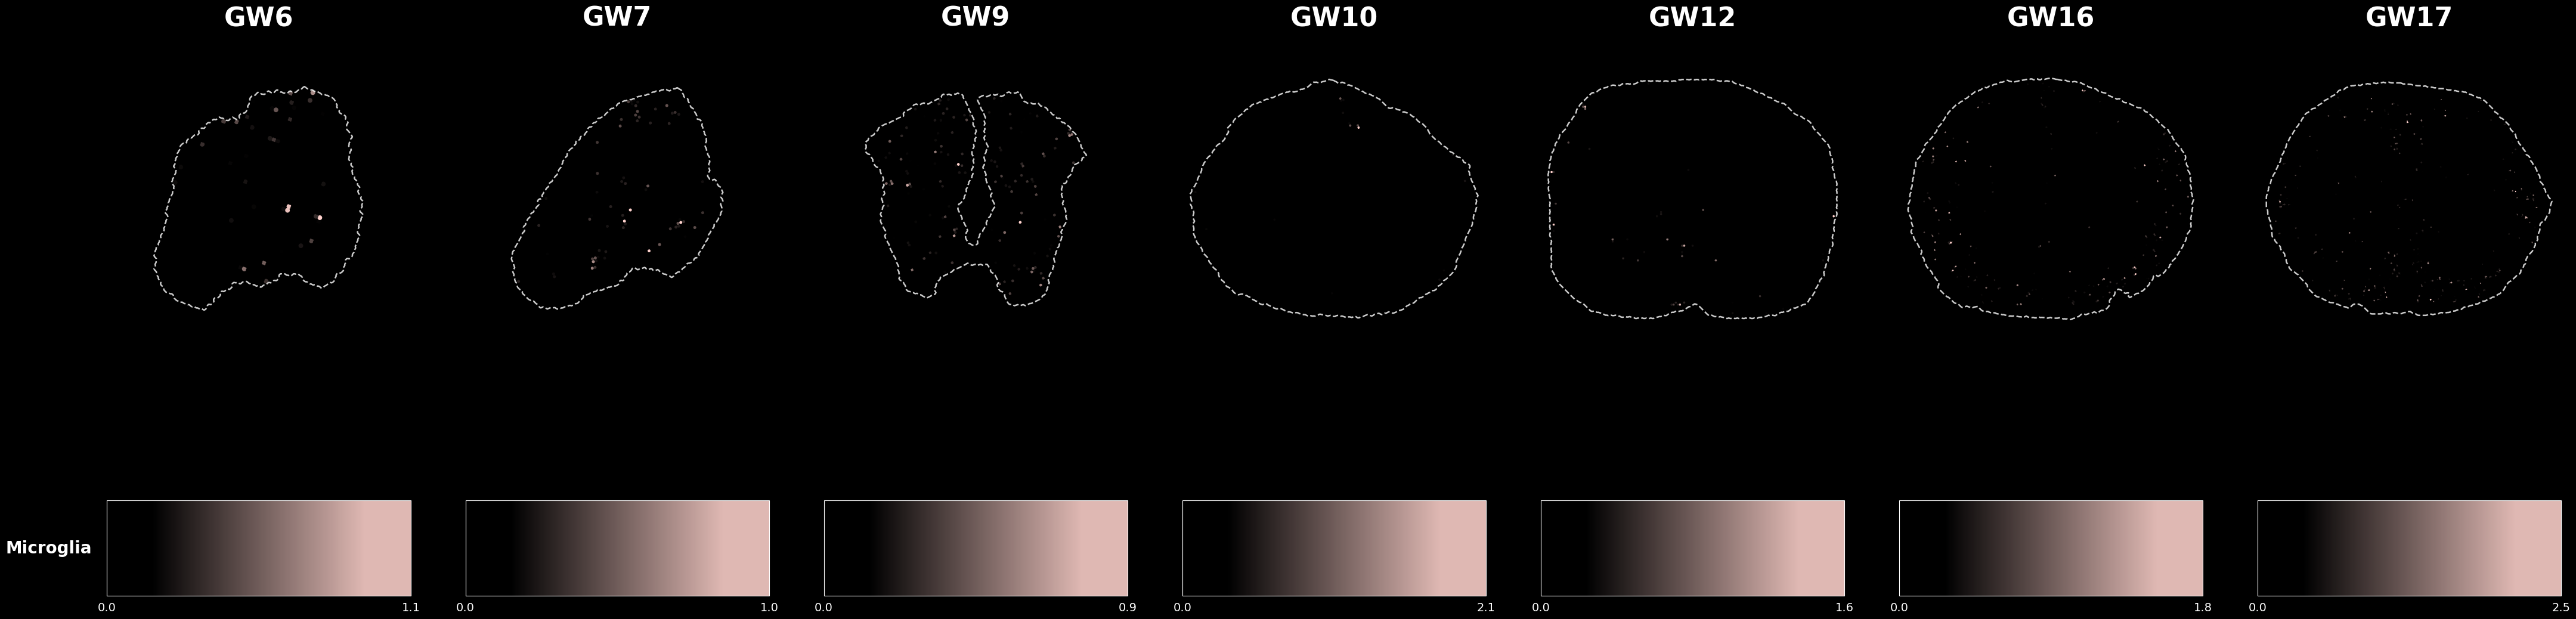

In [ ]:
import pandas as pd
import scanpy as sc
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, LinearSegmentedColormap, Normalize
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.ndimage import binary_dilation, gaussian_filter
from skimage import measure
import os

# ================== 1. Parameter configuration ==================
base_path = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/cell2location3/results/hsc_analysis/cell2location_map/'
csv_path = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/visualization3/spatial_coord.csv"

rotation_config = {
    "gw6": 250, "gw7": 17, "gw9": 205, "gw10": 200, "gw12": 180, "gw16": 125, "gw17": 284
}
sample_order = ["gw6", "gw7", "gw9", "gw10", "gw12", "gw16", "gw17"]

# ================== core functions ==================

def rotate_coords_geometric(coords, angle_degrees):
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(((c, -s), (s, c)))
    center = np.mean(coords, axis=0)
    return np.dot(coords - center, R.T) + center

def create_contrast_cmap(base_color):
    return LinearSegmentedColormap.from_list('contrast_cmap', [(0, 'black'), (0.15, 'black'), (0.85, base_color), (1, base_color)])

def plot_integrated_stereo_seq(sample_list, target_cts, my_colors, power=0.5):
    df_all_coords = pd.read_csv(csv_path, index_col=0)
    n_samples = len(sample_list)
    
    fig = plt.figure(figsize=(7 * n_samples, 14), facecolor='black')
    outer_gs = GridSpec(1, n_samples, figure=fig, wspace=0.18)

    for idx, s_id in enumerate(sample_list):
        print(f"Drawing {s_id}...")
        file_path = os.path.join(base_path, f"sp_{s_id}.h5ad")
        adata = sc.read_h5ad(file_path)
        sample_prefix = adata.obs_names[0].split(':')[0]
        df_f = df_all_coords[df_all_coords.index.str.startswith(sample_prefix)].copy()
        
        missing = df_f.index.difference(adata.obs_names)
        if len(missing) > 0:
            adata_m = ad.AnnData(X=np.zeros((len(missing), adata.n_vars)), 
                                 obs=pd.DataFrame(index=missing), var=adata.var.copy())
            adata = ad.concat([adata, adata_m], axis=0, join='outer', merge='first')
            num_cols = adata.obs.select_dtypes(include=[np.number]).columns
            adata.obs[num_cols] = adata.obs[num_cols].fillna(0)
        
        adata.obsm['spatial'] = df_f.loc[adata.obs_names, ['x', 'y']].values
        coords = rotate_coords_geometric(adata.obsm['spatial'], rotation_config[s_id])
        x, y = coords[:, 0], coords[:, 1]
        
        x_raw_min, x_raw_max = x.min(), x.max()
        y_raw_min, y_raw_max = y.min(), y.max()
        x_range = x_raw_max - x_raw_min
        y_range = y_raw_max - y_raw_min
        max_dim = max(x_range, y_range)
        
        # point size scaling
        auto_spot_size = (20000 / max_dim) * (10 / n_samples)
        if s_id in ["gw6"]:
            auto_spot_size *= 1.8

        # edge lines
        res = 200 
        mask = np.zeros((res + 60, res + 60)) 
        xi = ((x - x_raw_min) / max_dim * (res-1)).astype(int) + 30
        yi = ((y - y_raw_min) / max_dim * (res-1)).astype(int) + 30
        mask[yi, xi] = 1.0
        dilation_iter = int(np.sqrt(auto_spot_size) * 0.4) + 1 
        mask_dilated = binary_dilation(mask > 0.5, iterations=dilation_iter)
        mask_smoothed = gaussian_filter(mask_dilated.astype(float), sigma=0.8)
        contours = measure.find_contours(mask_smoothed, 0.5)

        # color processing
        mixed_rgb = np.zeros((adata.n_obs, 3))
        vmax_list = []
        intensities_list = []

        for ct in target_cts:
            base_color = my_colors.get(ct, '#FFFFFF')
            if ct in adata.obs.columns:
                w = adata.obs[ct].values.copy()
                actual_max = w.max()
            else:
                w = np.zeros(adata.n_obs)
                actual_max = 0.0
            
            # --- 【core modification: unify the scaling baseline, at least 0.5】 ---
            vmax_for_norm = max(0.5, actual_max) 
            vmax_list.append(actual_max) # record the actual maximum value for Colorbar use
            
            norm_w = np.power(np.interp(w/vmax_for_norm, [0, 0.2, 0.8, 1], [0, 0, 1, 1]), power)
            mixed_rgb += np.outer(norm_w, np.array(to_rgb(base_color)))
            intensities_list.append(np.interp(w/vmax_for_norm, [0, 0.2, 0.8, 1], [0, 0, 1, 1]))

        max_val = mixed_rgb.max(axis=1, keepdims=True)
        mixed_rgb /= np.where(max_val==0, 1, max_val)
        mixed_rgb *= np.max(intensities_list, axis=0)[:, np.newaxis]

        # layout
        inner_gs = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[idx], height_ratios=[8.5, 1.5], hspace=0.1)
        ax = fig.add_subplot(inner_gs[0])
        ax.set_facecolor('black')
        
        for contour in contours:
            cx = (contour[:, 1] - 30) / (res-1) * max_dim + x_raw_min
            cy = (contour[:, 0] - 30) / (res-1) * max_dim + y_raw_min
            ax.plot(cx, cy, color='white', linestyle='--', linewidth=1.8, alpha=0.8, zorder=10)

        ax.scatter(x, y, c=mixed_rgb, s=auto_spot_size, edgecolors='none', rasterized=True, zorder=5)
        
        # Zoom logic
        zoom_factor = 1.3 if s_id in ["gw10", "gw12", "gw16", "gw17"] else 1.0
        x_mid, y_mid = (x_raw_min + x_raw_max) / 2, (y_raw_min + y_raw_max) / 2
        safety_pad = 1.4 
        new_half = (max_dim / 2) / zoom_factor * safety_pad
        ax.set_xlim(x_mid - new_half, x_mid + new_half)
        ax.set_ylim(y_mid - new_half, y_mid + new_half)

        ax.set_title(s_id.upper(), color='white', fontsize=32, fontweight='bold', pad=25)
        ax.set_aspect('equal')
        ax.axis('off')

        # bottom Colorbars
        gs_cb = GridSpecFromSubplotSpec(len(target_cts), 1, subplot_spec=inner_gs[1], hspace=0.7)
        for i, ct in enumerate(target_cts):
            cax = fig.add_subplot(gs_cb[i])
            actual_v = vmax_list[i]
            
            # --- 【core modification: Colorbar range at least 1.0】 ---
            display_max = max(0.5, actual_v)
            norm = Normalize(0, display_max)
            
            sm = plt.cm.ScalarMappable(cmap=create_contrast_cmap(my_colors[ct]), norm=norm)
            cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
            cb.outline.set_edgecolor('white')
            
            # set ticks: display 0 and actual maximum value (if the maximum value is small, the ticks will be close to the left)
            ticks = [0, actual_v] if actual_v > 0.1 else [0, display_max]
            cb.set_ticks(ticks)
            cb.ax.set_xticklabels([f'{t:.1f}' for t in ticks], color='white', fontsize=14)
            
            if idx == 0: 
                cax.set_ylabel(ct, color='white', rotation=0, labelpad=70, va='center', fontsize=20, fontweight='bold')

    plt.subplots_adjust(left=0.08, right=0.92, top=0.9, bottom=0.1)
    return fig

# --- run ---
target_cts = ['NPC_proliferative', 'NPC']
target_cts = ['IPC', 'ExN_naive', 'InN_naive']
target_cts = ['ExN_immature_1', 'ExN_mature_1']
target_cts = ['ExN_immature_2', 'ExN_mature_2']
target_cts = ['ExN_immature_3', 'ExN_mature_3', 'ExN_ventral']
target_cts = ['InN_immature_1', 'InN_mature_1']
target_cts = ['InN_immature_2', 'InN_mature_2']
target_cts = ['InN_ventral_1', 'InN_ventral_2', 'InN_ventral_3']
target_cts = ['MN1', 'MN2']
target_cts = ['APC_cycling', 'AST']
target_cts = ['APC_dorsal', 'APC_ventral']
target_cts = ['OPC', 'COP', 'MFOL', 'MOL']
target_cts = ["RP", "MP", "FP"]
target_cts = ["EC"]
target_cts = ["VLMC"]
target_cts = ["PC"]
target_cts = ["Microglia"]

fig = plot_integrated_stereo_seq(sample_order, target_cts, my_colors, power=0.6)
plt.savefig('./c2l/C2l_Bin30_Microglia_lineage.pdf', dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

In [ ]:
target_celltypes = [
    "NPC_proliferative", "NPC", "IPC",
    "ExN_naive", "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral", 
    "InN_naive", "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3", 
    "MN1", "MN2", 
    "APC_cycling", "APC_dorsal", "APC_ventral", "AST",
    "OPC", "COP", "MFOL", "MOL", 
    "RP", "MP", "FP", 
    "Schwann", "EC", "VLMC", "PC", "Microglia"
]